In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time

In [2]:
# Naive (custom) function

def naive_matrix_multiplication(A, B):
    n = len(A)
    C = [[0] * n for _ in range(n)]
    
    for i in range(n):
        for j in range(n):
            for k in range(n):
                C[i][j] += A[i][k] * B[k][j]
    
    return C

In [3]:
# BLAS Initialization and First Call of Naive Function
# --> I was getting weird results for the first few matrix pairs,
#     and this is how the Stack Overflow forum says to fix that LOL
warmUp = naive_matrix_multiplication([[0]], [[0]])
warmUp = np.zeros((1, 1)) @ np.zeros((1, 1))

# Compare with optimized (numpy) function
numPairs = np.arange(1, 9)
naiveTimes = []
optimTimes = []
matrixSize = 3

for i in numPairs:
    # Make pair of random matrices
    A = np.random.randint(0, 10, size=(matrixSize, matrixSize))
    A_list = A.tolist()
    B = np.random.randint(0, 10, size=(matrixSize, matrixSize))
    B_list = B.tolist()
    
    # Naive
    startTime = time.perf_counter()
    C = naive_matrix_multiplication(A_list, B_list)
    endTime = time.perf_counter()
    naiveTotal = endTime - startTime
    naiveTimes.append(naiveTotal)
    
    # Optimized
    startTime = time.perf_counter()
    C = A @ B
    endTime = time.perf_counter()
    optimTotal = endTime - startTime
    optimTimes.append(optimTotal)
    
    # Print results
    print("Matrix Pair", i)
    print(f"Size: {matrixSize} x {matrixSize}")
    print("Naive Function Runtime:", naiveTotal)
    print("Optimized Function Runtime:", optimTotal)
    print("\n")
    
    matrixSize = matrixSize*2 # For next iteration
    
naiveTimes = np.asarray(naiveTimes)
optimTimes = np.asarray(optimTimes)

Matrix Pair 1
Size: 3 x 3
Naive Function Runtime: 1.5515834093093872e-05
Optimized Function Runtime: 9.719282388687134e-06


Matrix Pair 2
Size: 6 x 6
Naive Function Runtime: 5.580112338066101e-05
Optimized Function Runtime: 1.1362135410308838e-05


Matrix Pair 3
Size: 12 x 12
Naive Function Runtime: 0.0004642494022846222
Optimized Function Runtime: 2.078711986541748e-05


Matrix Pair 4
Size: 24 x 24
Naive Function Runtime: 0.0026576612144708633
Optimized Function Runtime: 4.112720489501953e-05


Matrix Pair 5
Size: 48 x 48
Naive Function Runtime: 0.023481449112296104
Optimized Function Runtime: 0.00017720460891723633


Matrix Pair 6
Size: 96 x 96
Naive Function Runtime: 0.16052133403718472
Optimized Function Runtime: 0.001068582758307457


Matrix Pair 7
Size: 192 x 192
Naive Function Runtime: 1.5002597253769636
Optimized Function Runtime: 0.011174187064170837


Matrix Pair 8
Size: 384 x 384
Naive Function Runtime: 11.149272767826915
Optimized Function Runtime: 0.1209831740707159




In [4]:
# Debugging
# print(len(numPairs))
# print(len(naiveTimes))
# print(len(optimTimes))

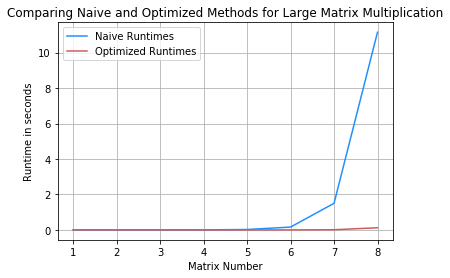

In [5]:
# Plotting
plt.figure()
plt.plot(numPairs, naiveTimes, color="dodgerblue", label="Naive Runtimes")
plt.plot(numPairs, optimTimes, color="indianred", label="Optimized Runtimes")
plt.title("Comparing Naive and Optimized Methods for Large Matrix Multiplication")
plt.xlabel("Matrix Number")
plt.ylabel("Runtime in seconds")
plt.legend()
plt.grid()
plt.show()